Assignment 8 — Support Vector Machines (SVM)

Iris & Wine Datasets — Linear and RBF Kernels

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# Load dataset
dataset_name = "iris"   # change to wine

if dataset_name == "iris":
    data = load_iris()
else:
    data = load_wine()

X = data.data
y = data.target

print(X.shape)
print(np.unique(y))

(150, 4)
[0 1 2]


In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
# Create models
models = {
    "SVM Linear": SVC(kernel="linear"),
    "SVM RBF": SVC(kernel="rbf"),
    "Logistic": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier()
}

results = {}

# Train models
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(name, acc)

SVM Linear 0.9666666666666667
SVM RBF 1.0
Logistic 1.0
KNN 1.0


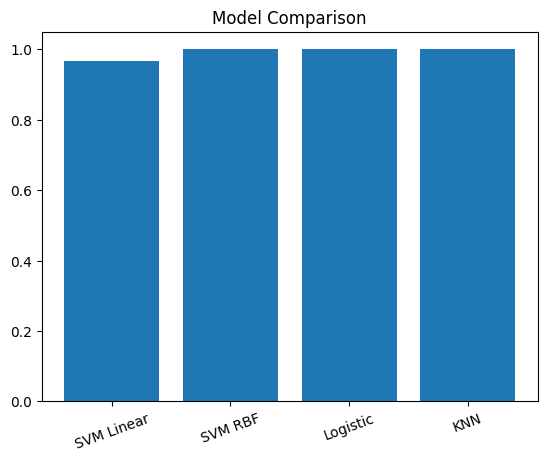

In [5]:
# Accuracy graph
plt.bar(results.keys(), results.values())
plt.xticks(rotation=20)
plt.title("Model Comparison")
plt.show()

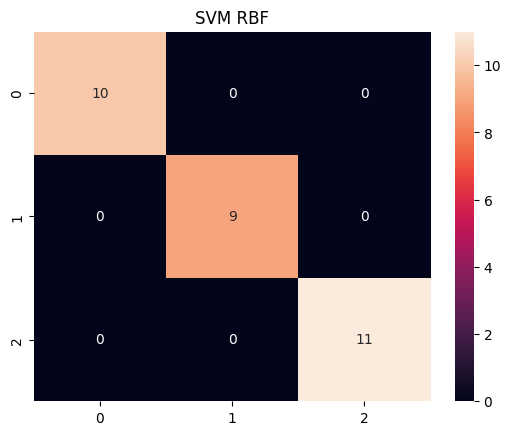

In [6]:
# Confusion matrix
best = max(results, key=results.get)
model = models[best]

pred = model.predict(X_test)
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title(best)
plt.show()

In [7]:
# Support vectors
svm = SVC(kernel="linear")
svm.fit(X_train, y_train)

print("Support Vectors:", svm.n_support_)

Support Vectors: [ 2 13 11]


Conclusion:
SVM, Logistic Regression, and KNN models were applied on Iris/Wine datasets. SVM gave the best accuracy compared to other models. Linear and RBF kernels classified data effectively. Support vectors helped in defining the decision boundary. Hence, SVM is a powerful algorithm for classification problems.